<a href="https://colab.research.google.com/github/FelipeFranciscoFerreira/Roteamento-Van-Otimizacao/blob/main/AG_VANS_Versao_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CÉLULA DE DADOS E CONFIGURAÇÕES DA ROTA

# Ponto de partida/retorno da Van (Garagem)
GARAGEM = (20, 80)

# Coordenadas Físicas dos 20 Alunos (ID: (x, y))
coords_alunos = {
    0: (25, 30), 1: (45, 15), 2: (60, 40), 3: (80, 25),
    4: (90, 50), 5: (15, 60), 6: (35, 80), 7: (55, 95),
    8: (75, 70), 9: (50, 55), 10: (20, 100), 11: (40, 120),
    12: (65, 110), 13: (85, 130), 14: (95, 105), 15: (10, 140),
    16: (30, 155), 17: (50, 135), 18: (70, 160), 19: (90, 145)
}

# Coordenadas Físicas das 5 Faculdades (ID: (x, y))
coords_faculdades = {
    0: (180, 50), 1: (200, 90), 2: (220, 130),
    3: (190, 170), 4: (210, 20)
}

# Mapeamento Fixo: Para qual faculdade cada aluno vai
destino_aluno = {
    0: 0, 1: 4, 2: 1, 3: 0, 4: 2,
    5: 1, 6: 3, 7: 2, 8: 1, 9: 0,
    10: 3, 11: 2, 12: 1, 13: 3, 14: 4,
    15: 3, 16: 2, 17: 0, 18: 3, 19: 4
}

# Zonas de Velocidade no Eixo Y ("Avenidas Verticais")
# Definidas por faixas da coordenada Y: (y_min, y_max) -> velocidade em km/h
SPEED_ZONES_Y = {
    (0, 80): 40,      # Ruas locais/bairros: 40 km/h
    (81, 160): 60,    # Avenidas principais: 60 km/h
    (161, 250): 80    # Vias expressas/rodovias: 80 km/h
}

# NOVA SEÇÃO: Zonas de Velocidade no Eixo X ("Avenidas Horizontais")
# Definidas por faixas da coordenada X: (x_min, x_max) -> velocidade em km/h
SPEED_ZONES_X = {
    (0, 100): 40,     # Zona urbana onde ficam os alunos: 50 km/h
    (101, 170): 80,   # Via rápida entre as duas áreas: 90 km/h
    (171, 250): 60   # Zona urbana onde ficam as faculdades: 45 km/h
}

print("Célula de dados (com velocidades em X e Y) carregada com sucesso!")

Célula de dados (com velocidades em X e Y) carregada com sucesso!


--- OTIMIZAÇÃO DE ROTA (VELOCIDADE EM X E Y) ---
Pesos: Dist=0.30, T.Van=0.20, T.Aluno=0.50
Gerando população com 14 alunos fixos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 19]

--- GERACAO: 0 ---
>> Melhor Rota (Custo: 481.90):  [np.int64(10), np.int64(6), np.int64(12), np.int64(2), np.int64(1), np.int64(5), np.int64(4), np.int64(3), np.int64(13), np.int64(19), np.int64(7), np.int64(0), np.int64(9), np.int64(8)]

--- GERACAO: 10 ---
>> Melhor Rota (Custo: 431.87):  [np.int64(5), np.int64(2), np.int64(3), np.int64(1), np.int64(6), np.int64(10), np.int64(0), np.int64(9), np.int64(7), np.int64(12), np.int64(13), np.int64(19), np.int64(4), np.int64(8)]

--- GERACAO: 20 ---
>> Melhor Rota (Custo: 407.29):  [np.int64(5), np.int64(0), np.int64(9), np.int64(2), np.int64(3), np.int64(1), np.int64(6), np.int64(10), np.int64(7), np.int64(12), np.int64(13), np.int64(19), np.int64(4), np.int64(8)]

--- GERACAO: 30 ---
>> Melhor Rota (Custo: 406.81):  [np.int64(10), np.int64(8), np.int64(3), np.in

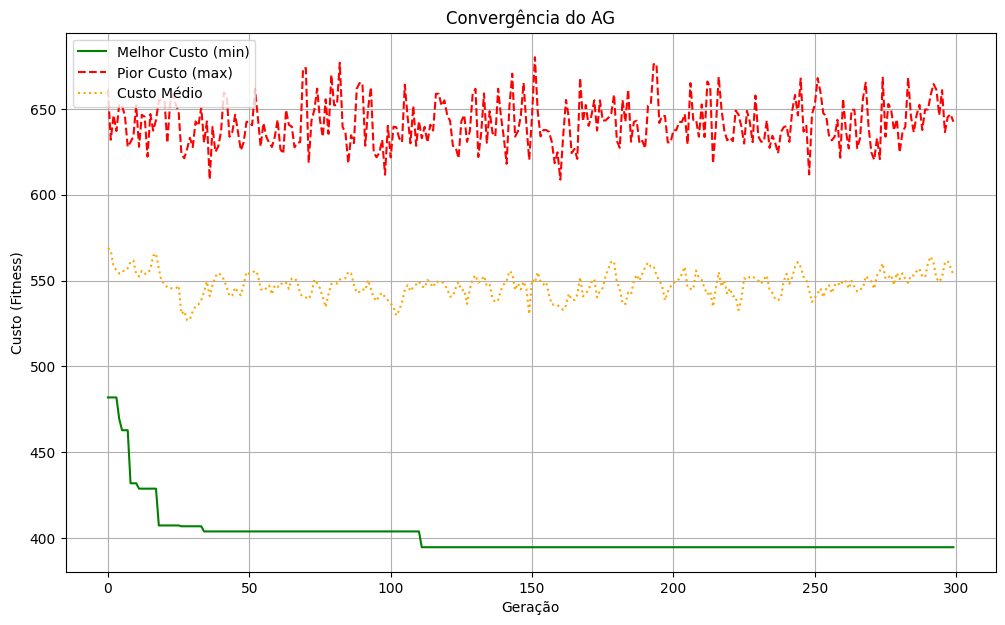


Exibindo mapa da MELHOR rota encontrada...


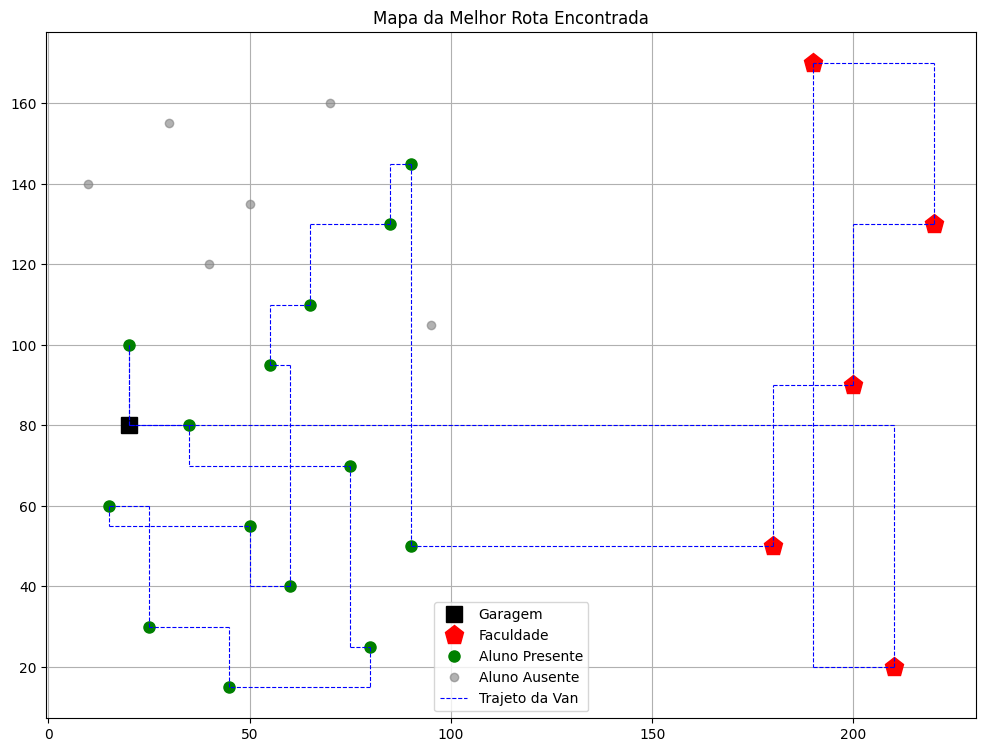


Exibindo mapa da PIOR rota encontrada durante a execução...


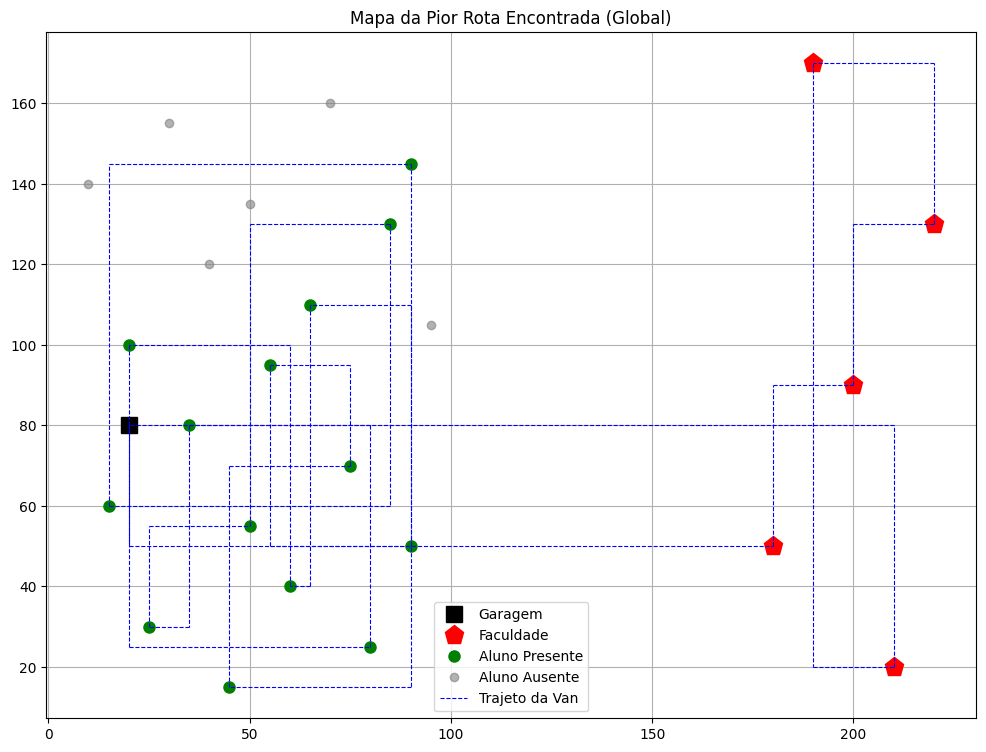

In [ ]:
# CÉLULA PRINCIPAL DO ALGORITMO GENÉTICO (PARA GOOGLE COLAB)
# Este código utiliza as variáveis definidas na célula de dados anterior.

import sys
import numpy as np
from numpy import random
import matplotlib.pyplot as plt

# HIPERPARÂMETROS DO ALGORITMO (AJUSTADOS PARA CONVERGÊNCIA MAIS LENTA)
TAM_POP = 100
MAX_GERACOES = 300
TAXA_CRUZAMENTO = 0.85
TAXA_MUTACAO = 0.02
QTD_ELITISMO = 2     # REDUZIDO: Menor pressão seletiva, convergência mais lenta.

# Define o grupo fixo de alunos presentes
ALUNOS_PRESENTES_FIXO = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 19]

# Pesos para a função de avaliação
W_DISTANCIA_RAW = 0.3
W_TEMPO_VAN_RAW = 0.2
W_TEMPO_ALUNO_RAW = 0.5
SOMA_PESOS = W_DISTANCIA_RAW + W_TEMPO_VAN_RAW + W_TEMPO_ALUNO_RAW
W_DISTANCIA = W_DISTANCIA_RAW / SOMA_PESOS
W_TEMPO_VAN = W_TEMPO_VAN_RAW / SOMA_PESOS
W_TEMPO_ALUNO = W_TEMPO_ALUNO_RAW / SOMA_PESOS

# --- VARIÁVEIS GLOBAIS DO AG ---
pop = []
nova_pop = []
nota_pop = np.zeros((TAM_POP, 3))

# --- FUNÇÕES AUXILIARES ---

def get_speed_for_y(y_coord):
    """Retorna a velocidade baseada na coordenada Y."""
    for zone, speed in SPEED_ZONES_Y.items():
        if zone[0] <= y_coord <= zone[1]:
            return speed
    return 40

def get_speed_for_x(x_coord):
    """Retorna a velocidade baseada na coordenada X."""
    for zone, speed in SPEED_ZONES_X.items():
        if zone[0] <= x_coord <= zone[1]:
            return speed
    return 45

def calcular_distancia(ponto1, ponto2):
    """Calcula a distância de Manhattan."""
    return abs(ponto1[0] - ponto2[0]) + abs(ponto1[1] - ponto2[1])

def calcular_tempo_manhattan(ponto1, ponto2):
    """Calcula o tempo de viagem, respeitando as zonas de velocidade em X e Y."""
    tempo_vertical = 0
    y1, y2 = ponto1[1], ponto2[1]
    if y1 != y2:
        incremento = 1 if y2 > y1 else -1
        for y_atual in range(y1, y2, incremento):
            tempo_vertical += 1 / get_speed_for_y(y_atual)

    tempo_horizontal = 0
    x1, x2 = ponto1[0], ponto2[0]
    if x1 != x2:
        incremento = 1 if x2 > x1 else -1
        for x_atual in range(x1, x2, incremento):
            tempo_horizontal += 1 / get_speed_for_x(x_atual)

    return tempo_vertical + tempo_horizontal

# --- FUNÇÕES DO ALGORITMO GENÉTICO ---

def init_pop():
    """Inicializa a população com o vetor FIXO de alunos."""
    global pop, ALUNOS_PRESENTES_FIXO
    pop = []
    print(f"Gerando população com {len(ALUNOS_PRESENTES_FIXO)} alunos fixos: {ALUNOS_PRESENTES_FIXO}")
    for _ in range(TAM_POP):
        pop.append(list(np.random.permutation(ALUNOS_PRESENTES_FIXO)))

def avalia_pop():
    """Função de Fitness. Calcula o custo de cada rota."""
    global nota_pop, W_DISTANCIA, W_TEMPO_VAN, W_TEMPO_ALUNO
    soma_apt_inversa = 0
    for i, rota in enumerate(pop):
        if not rota:
            nota_pop[i] = [i, float('inf'), 0]
            continue

        ponto_atual = GARAGEM
        dist_total = 0
        tempo_decorrido = 0
        tempo_embarque_aluno = {}
        tempos_alunos_bordo = []

        for aluno_id in rota:
            destino = coords_alunos[aluno_id]
            dist_total += calcular_distancia(ponto_atual, destino)
            tempo_viagem = calcular_tempo_manhattan(ponto_atual, destino)
            tempo_decorrido += tempo_viagem
            tempo_embarque_aluno[aluno_id] = tempo_decorrido
            tempo_decorrido += 2/60.0
            ponto_atual = destino

        faculdades_a_visitar = sorted(list(set([destino_aluno[aluno_id] for aluno_id in rota])))

        for facul_id in faculdades_a_visitar:
            destino = coords_faculdades[facul_id]
            dist_total += calcular_distancia(ponto_atual, destino)
            tempo_viagem = calcular_tempo_manhattan(ponto_atual, destino)
            tempo_decorrido += tempo_viagem
            for aluno_id in rota:
                if destino_aluno[aluno_id] == facul_id:
                    tempos_alunos_bordo.append(tempo_decorrido - tempo_embarque_aluno[aluno_id])
            tempo_decorrido += 5/60.0
            ponto_atual = destino

        dist = calcular_distancia(ponto_atual, GARAGEM)
        tempo_total_van = tempo_decorrido + calcular_tempo_manhattan(ponto_atual, GARAGEM)
        dist_total += dist
        tempo_medio_aluno = np.mean(tempos_alunos_bordo) if tempos_alunos_bordo else 0
        custo = (W_DISTANCIA * dist_total) + (W_TEMPO_VAN * tempo_total_van) + (W_TEMPO_ALUNO * tempo_medio_aluno)
        nota_pop[i] = [i, custo, 0]
        if custo > 0:
            soma_apt_inversa += 1 / custo

    nota_pop = nota_pop[nota_pop[:, 1].argsort()]
    acum = 0
    for i in range(TAM_POP):
        custo = nota_pop[i][1]
        prob = ((1 / custo) / soma_apt_inversa) if custo > 0 and soma_apt_inversa > 0 else 0
        nota_pop[i][2] = prob
        acum += prob
    if acum > 0:
        nota_pop[:, 2] /= acum

def seleciona_pais():
    r_pai1, r_pai2 = random.random_sample(), random.random_sample()
    pai1, pai2 = None, None
    acum = 0
    for i in range(TAM_POP):
        acum += nota_pop[i][2]
        if acum >= r_pai1 and pai1 is None: pai1 = pop[int(nota_pop[i][0])]
        if acum >= r_pai2 and pai2 is None: pai2 = pop[int(nota_pop[i][0])]
        if pai1 is not None and pai2 is not None: break
    return pai1, pai2

def cruza_pais(pai1, pai2):
    if not pai1 or not pai2: return pai1, pai2
    if random.random_sample() < TAXA_CRUZAMENTO:
        p1_subset = sorted(random.choice(len(pai1), 2, replace=False))
        parte_pai1 = pai1[p1_subset[0]:p1_subset[1]]
        resto_pai2 = [gene for gene in pai2 if gene not in parte_pai1]
        filho1 = parte_pai1 + resto_pai2
        p2_subset = sorted(random.choice(len(pai2), 2, replace=False))
        parte_pai2 = pai2[p2_subset[0]:p2_subset[1]]
        resto_pai1 = [gene for gene in pai1 if gene not in parte_pai2]
        filho2 = parte_pai2 + resto_pai1
        return filho1, filho2
    return pai1, pai2

def muta_filhos(filho):
    if not filho or len(filho) < 2: return filho
    for i in range(len(filho)):
        if random.random_sample() < TAXA_MUTACAO:
            j = random.randint(0, len(filho)-1)
            filho[i], filho[j] = filho[j], filho[i]
    return filho

def elitismo(qtde):
    global nova_pop
    for i in range(qtde):
        melhor_idx = int(nota_pop[i][0])
        nova_pop.append(pop[melhor_idx])

def imprime_melhor():
    melhor_idx = int(nota_pop[0][0])
    print(f">> Melhor Rota (Custo: {nota_pop[0][1]:.2f}): ", pop[melhor_idx])

def plotar_rota(rota, titulo):
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.set_title(titulo)
    ax.plot(GARAGEM[0], GARAGEM[1], 'ks', markersize=12, label='Garagem')
    for facul_id, coord in coords_faculdades.items():
        ax.plot(coord[0], coord[1], 'rp', markersize=14, label=f'Faculdade' if facul_id == 0 else "")
    for aluno_id, coord in coords_alunos.items():
        if aluno_id in rota:
            ax.plot(coord[0], coord[1], 'go', markersize=8, label='Aluno Presente' if aluno_id == rota[0] else "")
        else:
            ax.plot(coord[0], coord[1], 'o', markersize=6, color='gray', alpha=0.6, label='Aluno Ausente' if aluno_id not in rota else "")
    caminho_completo = [GARAGEM]
    caminho_completo.extend([coords_alunos[aluno_id] for aluno_id in rota])
    faculdades_a_visitar = sorted(list(set([destino_aluno[aluno_id] for aluno_id in rota])))
    caminho_completo.extend([coords_faculdades[facul_id] for facul_id in faculdades_a_visitar])
    caminho_completo.append(GARAGEM)
    for i in range(len(caminho_completo) - 1):
        p1 = caminho_completo[i]
        p2 = caminho_completo[i+1]
        label = 'Trajeto da Van' if i == 0 else ""
        ax.plot([p1[0], p1[0]], [p1[1], p2[1]], 'b--', lw=0.8, label=label)
        ax.plot([p1[0], p2[0]], [p2[1], p2[1]], 'b--', lw=0.8)
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())
    ax.grid(True)
    ax.set_aspect('equal', adjustable='box')
    plt.show()

# --- BLOCO DE EXECUÇÃO PRINCIPAL ---

if(__name__ == '__main__'):
    print("--- OTIMIZAÇÃO DE ROTA (VELOCIDADE EM X E Y) ---")
    print(f"Pesos: Dist={W_DISTANCIA:.2f}, T.Van={W_TEMPO_VAN:.2f}, T.Aluno={W_TEMPO_ALUNO:.2f}")
    init_pop()

    geracao, melhor, pior, medio = [], [], [], []

    pior_rota_global = None
    pior_custo_global = -1.0

    for i in range(MAX_GERACOES):
        avalia_pop()

        if i % 10 == 0:
             print(f'\n--- GERACAO: {i} ---')
             imprime_melhor()

        geracao.append(i)
        melhor.append(nota_pop[0][1])
        pior.append(nota_pop[-1][1])
        medio.append(np.mean(nota_pop[:, 1]))

        custo_pior_geracao = nota_pop[-1][1]
        if custo_pior_geracao > pior_custo_global:
            pior_custo_global = custo_pior_geracao
            pior_rota_global = pop[int(nota_pop[-1][0])].copy()

        nova_pop = []
        elitismo(QTD_ELITISMO)
        while len(nova_pop) < TAM_POP:
            p1, p2 = seleciona_pais()
            if p1 is None or p2 is None: continue
            f1, f2 = cruza_pais(list(p1), list(p2))
            nova_pop.append(muta_filhos(f1))
            if len(nova_pop) < TAM_POP:
                nova_pop.append(muta_filhos(f2))
        pop = nova_pop.copy()

    print('\n--- RESULTADO FINAL ---')
    avalia_pop()
    imprime_melhor()

    # --- PLOTAGEM DOS RESULTADOS ---

    # Gráfico de Convergência (Melhor, Pior e Médio)
    plt.figure(figsize=(12, 7))
    plt.title("Convergência do AG")
    plt.xlabel("Geração"); plt.ylabel("Custo (Fitness)")
    plt.plot(geracao, melhor, label="Melhor Custo (min)", color='green')
    # LINHAS REATIVADAS PARA VISUALIZAR MELHOR A CONVERGÊNCIA
    plt.plot(geracao, pior, label="Pior Custo (max)", color='red', linestyle='--')
    plt.plot(geracao, medio, label="Custo Médio", color='orange', linestyle=':')
    plt.legend(); plt.grid(True)
    plt.show()

    # Mapas de Rotas
    melhor_rota_final = pop[int(nota_pop[0][0])]
    print("\nExibindo mapa da MELHOR rota encontrada...")
    plotar_rota(melhor_rota_final, "Mapa da Melhor Rota Encontrada")

    print("\nExibindo mapa da PIOR rota encontrada durante a execução...")
    plotar_rota(pior_rota_global, "Mapa da Pior Rota Encontrada (Global)")